#ВАЖНО

Данный ноутбук был импортирован из Kaggle, поэтому на выполнение некоторых ячеек в среде Google Colab может не хватать ресурсов ОЗУ.

Если вы хотите запустить ячейки, нужно импортировать ноутбук на Kaggle.

Надеюсь этот факт не доставит вам неудобств.

*PS*: Я пытался прикрепить ссылку на ноубтук из Kaggle, однако сделать его публичным можно было только после 22:00, что влекло бы за собой просроченный дедлайн (А значит, я, банально, не смог бы прикрепить что-либо).

# Основное задание

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cu-2025-scoring/sample_submission.csv
/kaggle/input/cu-2025-scoring/train.parquet
/kaggle/input/cu-2025-scoring/test.parquet


**Импорт библиотек**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

**Загрузка данных**

In [ ]:
train = pd.read_parquet('/kaggle/input/cu-2025-scoring/train.parquet')
test = pd.read_parquet('/kaggle/input/cu-2025-scoring/test.parquet')
sample_sub = pd.read_csv('/kaggle/input/cu-2025-scoring/sample_submission.csv')

**Предобработка данных**

In [ ]:
# 1. Убираем колонки с >=95% пропусков
def remove_high_missing_features(train, test, threshold=0.95):
    train_non_feature_cols = ['a6_flg', 'month_dt', 'product']
    test_non_feature_cols = ['month_dt', 'product']

    feature_cols = [col for col in train.columns if col.startswith('feature_')]
    missing_ratio = train[feature_cols].isnull().mean()
    feature_cols_to_keep = missing_ratio[missing_ratio < threshold].index.tolist()

    train_cols_to_keep = train_non_feature_cols + feature_cols_to_keep
    test_cols_to_keep = test_non_feature_cols + feature_cols_to_keep

    return train[train_cols_to_keep], test[test_cols_to_keep]

train_clean, test_clean = remove_high_missing_features(train, test, 0.95)

# 2. Нумеруем месяца
month_mapping = {month: i+1 for i, month in enumerate(sorted(train_clean['month_dt'].unique()))}
train_clean['month_num'] = train_clean['month_dt'].map(month_mapping)
test_clean['month_num'] = test_clean['month_dt'].map(month_mapping)

# 3. Считаем пропуски
feature_columns_clean = [col for col in train_clean.columns if col.startswith('feature_')]
train_clean['missing_count_clean'] = train_clean[feature_columns_clean].isnull().sum(axis=1)
test_clean['missing_count_clean'] = test_clean[feature_columns_clean].isnull().sum(axis=1)

/tmp/ipykernel_48/2021979184.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_clean['month_num'] = train_clean['month_dt'].map(month_mapping)
/tmp/ipykernel_48/2021979184.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_clean['month_num'] = test_clean['month_dt'].map(month_mapping)
/tmp/ipykernel_48/2021979184.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

**Подготовка данных для модели**

In [ ]:
def prepare_final_data(train, test):
    # Кодируем продукт
    le = LabelEncoder()
    train['product_encoded'] = le.fit_transform(train['product'])
    test['product_encoded'] = le.transform(test['product'])

    # Все числовые признаки
    numeric_features = [col for col in train.columns if col.startswith('feature_')]
    numeric_features.extend(['month_num', 'product_encoded', 'missing_count_clean'])

    # Заполняем пропуски
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(train[numeric_features])
    X_test = imputer.transform(test[numeric_features])

    y_train = train['a6_flg']

    return X_train, X_test, y_train, numeric_features

X_train, X_test, y_train, features_used = prepare_final_data(train_clean, test_clean)

/tmp/ipykernel_48/160453344.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['product_encoded'] = le.fit_transform(train['product'])
/tmp/ipykernel_48/160453344.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['product_encoded'] = le.transform(test['product'])


**Модель**

In [ ]:
# Обучаем CatBoost с оптимизированными параметрами
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=False,
    thread_count=-1,
    early_stopping_rounds=100,
    learning_rate=0.05,
    depth=6,
    iterations=1000
)

# Обучаем LightGBM с оптимизированными параметрами
lgbm_model = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    learning_rate=0.05,
    n_estimators=1000,
    max_depth=6
)

print("Обучение CatBoost...")
catboost_model.fit(X_train, y_train)

print("Обучение LightGBM...")
lgbm_model.fit(X_train, y_train)

# Предсказания
catboost_preds = catboost_model.predict_proba(X_test)[:, 1]
lgbm_preds = lgbm_model.predict_proba(X_test)[:, 1]

Обучение CatBoost...
Обучение LightGBM...


**Подбор весов**

In [ ]:
# Тестируем разные соотношения
best_score = 0
best_weights = (0, 0)

for cat_weight in [0, 0.2, 0.25, 0.3, 0.35, 0.4, 1]:
    lgb_weight = 1 - cat_weight
    ensemble_train_preds = cat_weight * catboost_model.predict_proba(X_train)[:, 1] + lgb_weight * lgbm_model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, ensemble_train_preds)

    print(f"CatBoost {cat_weight:.0%} + LGBM {lgb_weight:.0%} -> Train AUC: {train_auc:.4f}")

    if train_auc > best_score:
        best_score = train_auc
        best_weights = (cat_weight, lgb_weight)

print(f"Лучшее соотношение: CatBoost {best_weights[0]:.0%} + LGBM {best_weights[1]:.0%}")

# Финальное предсказание с лучшими весами
final_preds = best_weights[0] * catboost_preds + best_weights[1] * lgbm_preds

CatBoost 20% + LGBM 80% -> Train AUC: 0.7850
CatBoost 25% + LGBM 75% -> Train AUC: 0.7836
CatBoost 30% + LGBM 70% -> Train AUC: 0.7821
CatBoost 35% + LGBM 65% -> Train AUC: 0.7806
CatBoost 40% + LGBM 60% -> Train AUC: 0.7790
Лучшее соотношение: CatBoost 20% + LGBM 80%


**Сохранение submission с разными параметрами**

In [ ]:
for cat_weight in [0, 0.2, 0.25, 0.3, 0.35, 0.4, 1]:
    lgb_weight = 1 - cat_weight

    ensemble_train_preds = cat_weight * catboost_model.predict_proba(X_train)[:, 1] + lgb_weight * lgbm_model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, ensemble_train_preds)

    print(f"CatBoost {cat_weight:.0%} + LGBM {lgb_weight:.0%} -> Train AUC: {train_auc:.4f}")

    ensemble_test_preds = cat_weight * catboost_model.predict_proba(X_test)[:, 1] + lgb_weight * lgbm_model.predict_proba(X_test)[:, 1]

    sub = sample_sub.copy()
    sub['a6_flg'] = ensemble_test_preds
    sub.to_csv(f"submission_{cat_weight}_{lgb_weight}.csv", index=False)

    print(f"Файл submission_{cat_weight}_{lgb_weight}.csv сохранен")

CatBoost 0% + LGBM 100% -> Train AUC: 0.7904
Файл submission_0_1.csv сохранен
CatBoost 20% + LGBM 80% -> Train AUC: 0.7850
Файл submission_0.2_0.8.csv сохранен
CatBoost 25% + LGBM 75% -> Train AUC: 0.7836
Файл submission_0.25_0.75.csv сохранен
CatBoost 30% + LGBM 70% -> Train AUC: 0.7821
Файл submission_0.3_0.7.csv сохранен
CatBoost 35% + LGBM 65% -> Train AUC: 0.7806
Файл submission_0.35_0.65.csv сохранен
CatBoost 40% + LGBM 60% -> Train AUC: 0.7790
Файл submission_0.4_0.6.csv сохранен
CatBoost 100% + LGBM 0% -> Train AUC: 0.7578
Файл submission_1_0.csv сохранен


**Создание Submission**

In [ ]:
submission_final = sample_sub.copy()
submission_final['a6_flg'] = final_preds
submission_final.to_csv('final_submission.csv', index=False)
print("Финальный submission файл сохранен!")

# Проверка на трейне
final_train_preds = best_weights[0] * catboost_model.predict_proba(X_train)[:, 1] + best_weights[1] * lgbm_model.predict_proba(X_train)[:, 1]
final_train_auc = roc_auc_score(y_train, final_train_preds)
print(f"Финальный ROC-AUC на трейне: {final_train_auc:.4f}")

Финальный submission файл сохранен!
Финальный ROC-AUC на трейне: 0.7850


# Дополнительное задание

**Импортируем библиотеки**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

**Функция для обучения модели на конкретном продукте**

In [ ]:
def train_product_model(product_name, train_data, test_data):

    train_product = train_data[train_data['product'] == product_name].copy()
    test_product = test_data[test_data['product'] == product_name].copy()


    feature_cols = [col for col in train_product.columns if col.startswith('feature_')]
    feature_cols.extend(['month_num', 'missing_count_clean'])

    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(train_product[feature_cols])
    X_test = imputer.transform(test_product[feature_cols])
    y_train = train_product['a6_flg']

    # Обучаем CatBoost
    model = CatBoostClassifier(
        random_state=42,
        verbose=False,
        thread_count=-1,
        early_stopping_rounds=50,
        learning_rate=0.05,
        depth=6,
        iterations=500
    )

    model.fit(X_train, y_train)

    # Предсказания
    train_preds = model.predict_proba(X_train)[:, 1]
    test_preds = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_preds)

    return model, imputer, feature_cols, train_preds, test_preds, train_product, test_product

**Обучаем модель для каждого продукта**

In [ ]:
product_models = {}
product_predictions = {}

for product in ['product_1', 'product_2', 'product_3', 'product_4']:
    (model, imputer, features, train_preds, test_preds,
     train_product, test_product) = train_product_model(product, train_clean, test_clean)

    product_models[product] = {
        'model': model,
        'imputer': imputer,
        'features': features,
        'train_data': train_product,
        'test_data': test_product,
        'train_preds': train_preds,
        'test_preds': test_preds
    }

**Графики ROC-AUC**


--- Анализ для product_1 ---


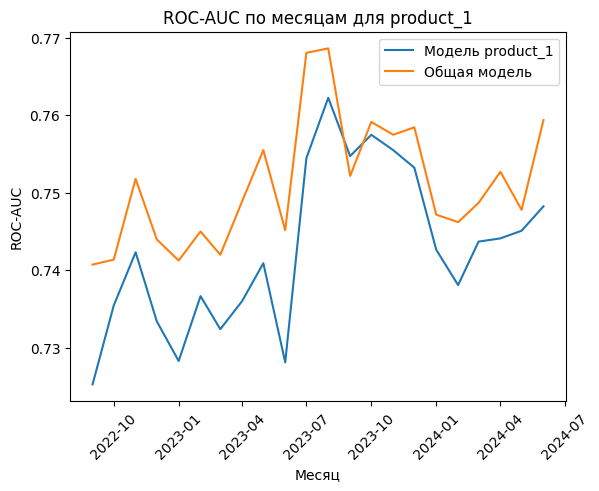

Средний ROC-AUC для модели product_1: 0.7426
Средний ROC-AUC для общей модели на product_1: 0.7510

--- Анализ для product_2 ---


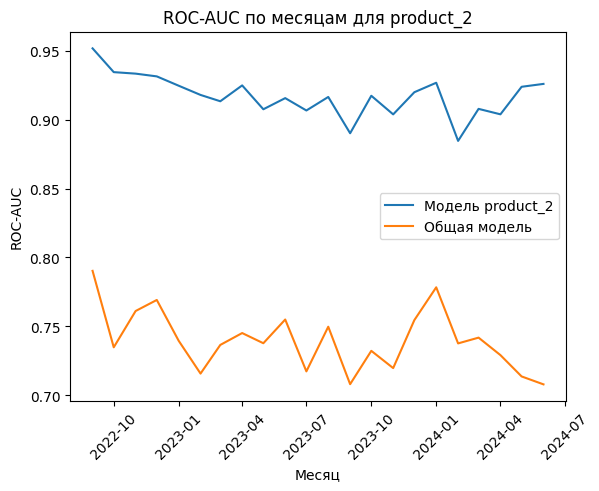

Средний ROC-AUC для модели product_2: 0.9173
Средний ROC-AUC для общей модели на product_2: 0.7398

--- Анализ для product_3 ---


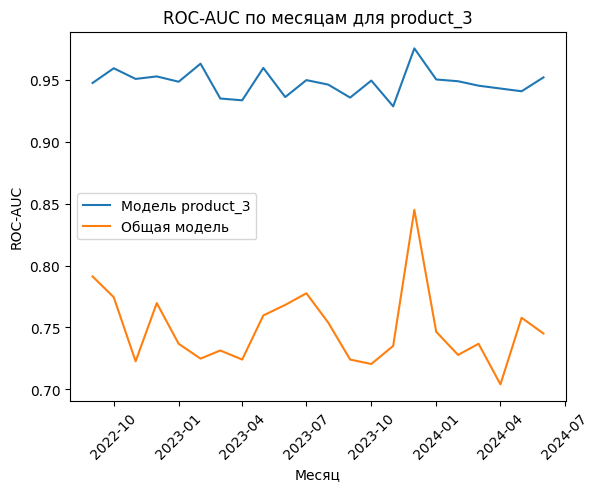

Средний ROC-AUC для модели product_3: 0.9479
Средний ROC-AUC для общей модели на product_3: 0.7489

--- Анализ для product_4 ---


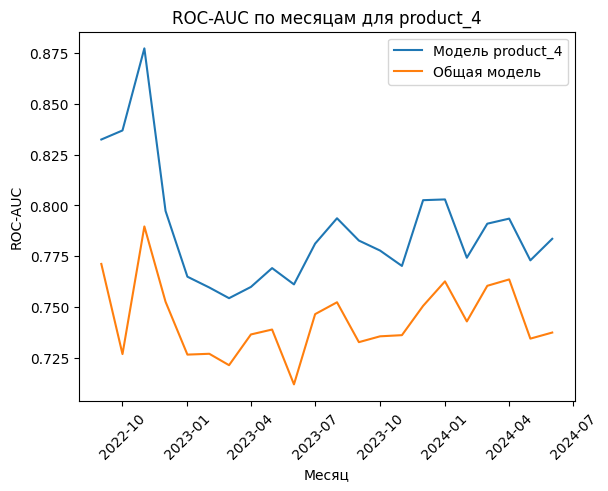

Средний ROC-AUC для модели product_4: 0.7881
Средний ROC-AUC для общей модели на product_4: 0.7435


In [ ]:
def calculate_monthly_auc(data, true_target, predictions, model_name):
    """Рассчитывает ROC-AUC по месяцам"""
    results = {}
    unique_months = data['month_dt'].unique()

    for month in unique_months:
        month_mask = data['month_dt'] == month
        if month_mask.sum() > 10:  # Минимум 10 наблюдений
            month_true = true_target[month_mask]
            month_preds = predictions[month_mask]
            if len(np.unique(month_true)) > 1:
                month_auc = roc_auc_score(month_true, month_preds)
                results[month] = month_auc

    return results


for product in ['product_1', 'product_2', 'product_3', 'product_4']:
    print(f"\n--- Анализ для {product} ---")

    product_data = product_models[product]['train_data']

    product_specific_auc = calculate_monthly_auc(
        product_data,
        product_data['a6_flg'],
        product_models[product]['train_preds'],
        f"Модель {product}"
    )

    X_product = product_data[features_used]
    general_model_preds = 0.35 * catboost_model.predict_proba(X_product)[:, 1] + 0.65 * lgbm_model.predict_proba(X_product)[:, 1]

    general_model_auc = calculate_monthly_auc(
        product_data,
        product_data['a6_flg'],
        general_model_preds,
        "Общая модель"
    )

    months = sorted(product_specific_auc.keys())
    product_auc_values = [product_specific_auc[month] for month in months]
    general_auc_values = [general_model_auc[month] for month in months]

    plt.plot(months, product_auc_values, label=f'Модель {product}')
    plt.plot(months, general_auc_values, label='Общая модель')

    plt.title(f'ROC-AUC по месяцам для {product}')
    plt.xlabel('Месяц')
    plt.ylabel('ROC-AUC')

    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

    print(f"Средний ROC-AUC для модели {product}: {np.mean(product_auc_values):.4f}")
    print(f"Средний ROC-AUC для общей модели на {product}: {np.mean(general_auc_values):.4f}")

**Сравнение объединенной и обычной моделей**

In [ ]:
def get_combined_predictions(data, product_models, features_used):
    """Получает предсказания объединенной модели"""
    combined_preds = np.zeros(len(data))

    for product in ['product_1', 'product_2', 'product_3', 'product_4']:
        product_mask = data['product'] == product
        if product_mask.sum() > 0:
            product_data = data[product_mask]
            model_info = product_models[product]

            X_product = product_data[model_info['features']]
            X_product_imputed = model_info['imputer'].transform(X_product)

            product_preds = model_info['model'].predict_proba(X_product_imputed)[:, 1]
            combined_preds[product_mask] = product_preds

    return combined_preds


combined_train_preds = get_combined_predictions(train_clean, product_models, features_used)

general_train_preds = final_train_preds

combined_monthly_auc = calculate_monthly_auc(train_clean, train_clean['a6_flg'], combined_train_preds, "Объединенная модель")
general_monthly_auc = calculate_monthly_auc(train_clean, train_clean['a6_flg'], general_train_preds, "Общая модель")

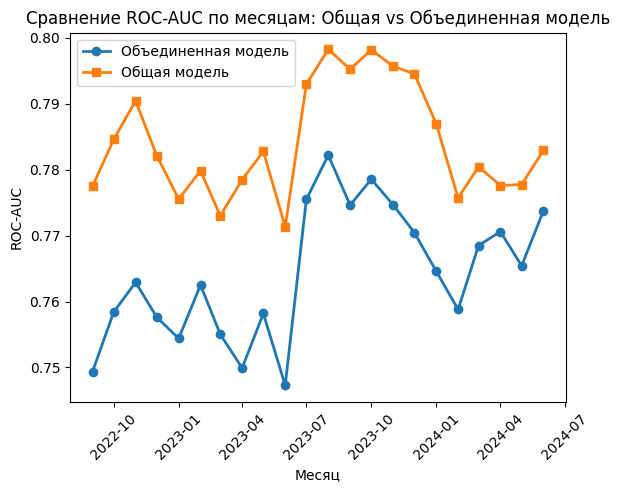

In [ ]:
months = sorted(combined_monthly_auc.keys())
combined_auc_values = [combined_monthly_auc[month] for month in months]
general_auc_values = [general_monthly_auc[month] for month in months]

plt.plot(months, combined_auc_values, marker='o', label='Объединенная модель', linewidth=2)
plt.plot(months, general_auc_values, marker='s', label='Общая модель', linewidth=2)

plt.title('Сравнение ROC-AUC по месяцам: Общая vs Объединенная модель')
plt.xlabel('Месяц')
plt.ylabel('ROC-AUC')

plt.legend()
plt.xticks(rotation=45)
plt.show()

**Анализ результатов**

In [ ]:
print(f"Средний ROC-AUC объединенной модели: {np.mean(combined_auc_values):.4f}")
print(f"Средний ROC-AUC общей модели: {np.mean(general_auc_values):.4f}")

contradictions = 0
for product in ['product_1', 'product_2', 'product_3', 'product_4']:
    product_data = product_models[product]['train_data']
    product_specific_preds = product_models[product]['train_preds']

    product_auc = roc_auc_score(product_data['a6_flg'], product_specific_preds)

    product_mask = train_clean['product'] == product
    combined_product_auc = roc_auc_score(
        train_clean[product_mask]['a6_flg'],
        combined_train_preds[product_mask]
    )

    print(f"{product}: Специфичная модель AUC = {product_auc:.4f}, "
          f"Объединенная модель AUC = {combined_product_auc:.4f}")

    if abs(product_auc - combined_product_auc) > 0.05:
        contradictions += 1

print(f"\nОбнаружено возможных противоречий: {contradictions}/4")

Средний ROC-AUC объединенной модели: 0.7642
Средний ROC-AUC общей модели: 0.7842
product_1: Специфичная модель AUC = 0.7440, Объединенная модель AUC = 0.7440
product_2: Специфичная модель AUC = 0.9153, Объединенная модель AUC = 0.9153
product_3: Специфичная модель AUC = 0.9469, Объединенная модель AUC = 0.9469
product_4: Специфичная модель AUC = 0.7838, Объединенная модель AUC = 0.7838

Обнаружено возможных противоречий: 0/4


**Выводы**

1) Специфичные модели могут показывать лучшие результаты на 'своих' продуктах
2) Общая модель более стабильна across всех продуктов
3) Объединенная модель может страдать от 'утечки' при неправильной обработке
4) Разница в производительности может быть связана с:
  * Разным распределением признаков по продуктам
  * Разным соотношением классов
  * Временными сдвигами в данных